In [24]:
import glob
import re
import numpy as np
import xarray as xr
import pandas as pd
from datetime import datetime, timedelta
import matplotlib.pyplot as plt

In [25]:

# Fixed base directory
base_dir = "/home/jovyan/SAMBBA_data/dap.ceda.ac.uk/badc/faam/data/2012"

# List of target subdirectories
dirs = [
    "b729-aug-28", "b730-sep-04", "b731-sep-14", "b732-sep-15", "b733-sep-16", 
    "b734-sep-18", "b735-sep-19", "b736-sep-19", "b737-sep-20", "b738-sep-22", 
    "b739-sep-23", "b740-sep-25", "b741-sep-26", "b742-sep-27", "b743-sep-27", 
    "b744-sep-28", "b745-sep-28", "b746-sep-29", "b747-oct-01", "b748-oct-02", 
    "b749-oct-03", "b750-oct-03"
]


In [26]:
# Initialize a list to store file paths
file_paths = []

# Iterate over each directory and collect .nc files from 'core_processed'
for d in dirs:
    path = f"{base_dir}/{d}/core_processed/core_faam*r1*.nc"
    file_paths.extend(sorted(glob.glob(path)))

# Print or use the collected file paths
print(file_paths)

['/home/jovyan/SAMBBA_data/dap.ceda.ac.uk/badc/faam/data/2012/b729-aug-28/core_processed/core_faam_20120828_v004_r1_b729.nc', '/home/jovyan/SAMBBA_data/dap.ceda.ac.uk/badc/faam/data/2012/b729-aug-28/core_processed/core_faam_20120828_v004_r1_b729_1hz.nc', '/home/jovyan/SAMBBA_data/dap.ceda.ac.uk/badc/faam/data/2012/b730-sep-04/core_processed/core_faam_20120904_v004_r1_b730.nc', '/home/jovyan/SAMBBA_data/dap.ceda.ac.uk/badc/faam/data/2012/b730-sep-04/core_processed/core_faam_20120904_v004_r1_b730_1hz.nc', '/home/jovyan/SAMBBA_data/dap.ceda.ac.uk/badc/faam/data/2012/b731-sep-14/core_processed/core_faam_20120914_v004_r1_b731.nc', '/home/jovyan/SAMBBA_data/dap.ceda.ac.uk/badc/faam/data/2012/b731-sep-14/core_processed/core_faam_20120914_v004_r1_b731_1hz.nc', '/home/jovyan/SAMBBA_data/dap.ceda.ac.uk/badc/faam/data/2012/b732-sep-15/core_processed/core_faam_20120915_v004_r1_b732.nc', '/home/jovyan/SAMBBA_data/dap.ceda.ac.uk/badc/faam/data/2012/b732-sep-15/core_processed/core_faam_20120915_v004_

In [27]:
# List to store filtered file paths
filtered_files = []

# Iterate over each directory and collect .nc files from 'core_processed'
for d in dirs:
    path = f"{base_dir}/{d}/core_processed/core_faam*r1*.nc"
    all_files = sorted(glob.glob(path))  # Get all r1 files
    
    # Print files found for debugging
    #print(f"Files found in {path}:")
    #print(all_files)
    
    # Filter out files that contain "_1hz"
    for file in all_files:
        if "_1hz" not in file:  # Exclude _1hz files
            filtered_files.append(file)

# Print or use the collected file paths
#print("\nFiltered files:")
#print(filtered_files)


In [28]:
# Initialize a list to store file paths
file_paths_ams = []

# Iterate over each directory and collect .nc files from 'core_processed'
for d in dirs:
    path = f"{base_dir}/{d}/non-core/man-ams*.na"
    file_paths_ams.extend(sorted(glob.glob(path)))

# Print or use the collected file paths
#print(file_paths_ams)

In [29]:
# Initialize a list to store file paths
file_paths_sp2 = []

# Iterate over each directory and collect .nc files from 'core_processed'
for d in dirs:
    path = f"{base_dir}/{d}/non-core/man-sp2*.na"
    file_paths_sp2.extend(sorted(glob.glob(path)))

# Print or use the collected file paths
#print(file_paths_sp2)

In [30]:
# Function to extract flight number (e.g., "b734") from a file path
def extract_flight_number(file_path):
    match = re.search(r'b\d{3}', file_path)
    return match.group(0) if match else None  # Returns None if no match

# Get flight numbers for each dataset
flights_nc = {extract_flight_number(f) for f in filtered_files}
flights_ams = {extract_flight_number(f) for f in file_paths_ams}
flights_sp2 = {extract_flight_number(f) for f in file_paths_sp2}

# Find flights that are in all three datasets
common_flights = flights_nc & flights_ams & flights_sp2  # Set intersection

# Filter the file lists to include only matching flights
filtered_nc = [f for f in filtered_files if extract_flight_number(f) in common_flights]
filtered_ams = [f for f in file_paths_ams if extract_flight_number(f) in common_flights]
filtered_sp2 = [f for f in file_paths_sp2 if extract_flight_number(f) in common_flights]

# Print the results
print(f"Common flights: {sorted(common_flights)}")
print(f"Filtered NC files: {len(filtered_nc)}")
print(f"Filtered AMS files: {len(filtered_ams)}")
print(f"Filtered SP2 files: {len(filtered_sp2)}")


Common flights: ['b731', 'b734', 'b737', 'b739', 'b740', 'b741', 'b742', 'b743', 'b744', 'b745', 'b746', 'b747', 'b748', 'b749', 'b750']
Filtered NC files: 15
Filtered AMS files: 15
Filtered SP2 files: 15


In [31]:
filtered_nc

['/home/jovyan/SAMBBA_data/dap.ceda.ac.uk/badc/faam/data/2012/b731-sep-14/core_processed/core_faam_20120914_v004_r1_b731.nc',
 '/home/jovyan/SAMBBA_data/dap.ceda.ac.uk/badc/faam/data/2012/b734-sep-18/core_processed/core_faam_20120918_v004_r1_b734.nc',
 '/home/jovyan/SAMBBA_data/dap.ceda.ac.uk/badc/faam/data/2012/b737-sep-20/core_processed/core_faam_20120920_v004_r1_b737.nc',
 '/home/jovyan/SAMBBA_data/dap.ceda.ac.uk/badc/faam/data/2012/b739-sep-23/core_processed/core_faam_20120923_v004_r1_b739.nc',
 '/home/jovyan/SAMBBA_data/dap.ceda.ac.uk/badc/faam/data/2012/b740-sep-25/core_processed/core_faam_20120925_v004_r1_b740.nc',
 '/home/jovyan/SAMBBA_data/dap.ceda.ac.uk/badc/faam/data/2012/b741-sep-26/core_processed/core_faam_20120926_v004_r1_b741.nc',
 '/home/jovyan/SAMBBA_data/dap.ceda.ac.uk/badc/faam/data/2012/b742-sep-27/core_processed/core_faam_20120927_v004_r1_b742.nc',
 '/home/jovyan/SAMBBA_data/dap.ceda.ac.uk/badc/faam/data/2012/b743-sep-27/core_processed/core_faam_20120927_v004_r1_b7

In [32]:
filtered_sp2

['/home/jovyan/SAMBBA_data/dap.ceda.ac.uk/badc/faam/data/2012/b731-sep-14/non-core/man-sp2_faam_20120914_r0_b731.na',
 '/home/jovyan/SAMBBA_data/dap.ceda.ac.uk/badc/faam/data/2012/b734-sep-18/non-core/man-sp2_faam_20120918_r0_b734.na',
 '/home/jovyan/SAMBBA_data/dap.ceda.ac.uk/badc/faam/data/2012/b737-sep-20/non-core/man-sp2_faam_20120920_r0_b737.na',
 '/home/jovyan/SAMBBA_data/dap.ceda.ac.uk/badc/faam/data/2012/b739-sep-23/non-core/man-sp2_faam_20120923_r0_b739.na',
 '/home/jovyan/SAMBBA_data/dap.ceda.ac.uk/badc/faam/data/2012/b740-sep-25/non-core/man-sp2_faam_20120925_r0_b740.na',
 '/home/jovyan/SAMBBA_data/dap.ceda.ac.uk/badc/faam/data/2012/b741-sep-26/non-core/man-sp2_faam_20120926_r0_b741.na',
 '/home/jovyan/SAMBBA_data/dap.ceda.ac.uk/badc/faam/data/2012/b742-sep-27/non-core/man-sp2_faam_20120927_r0_b742.na',
 '/home/jovyan/SAMBBA_data/dap.ceda.ac.uk/badc/faam/data/2012/b743-sep-27/non-core/man-sp2_faam_20120927_r0_b743.na',
 '/home/jovyan/SAMBBA_data/dap.ceda.ac.uk/badc/faam/data

In [33]:
filtered_sp2[0]

# Extract the date (format: yyyymmdd)
match = re.search(r'(\d{8})', filtered_sp2[0])

# Get the matched date or None if not found
flight_date = match.group(1) if match else None

print(flight_date)  # Output: 20120914

20120914


In [34]:
def convert_time_to_datetime_sp2(dsf, start_date_str):
    """
    Convert the 'Time_start_UTC' variable (seconds from 00:00 UTC) into datetime format.
    
    Parameters:
    - ds (xarray.Dataset): The dataset containing 'Time_start_UTC'
    - start_date_str (str): Start date in "YYYY MM DD" format
    
    Returns:
    - xarray.Dataset: Dataset with a new 'datetime' coordinate
    """
    # Convert start_date string to datetime object
    start_date = datetime.strptime(start_date_str, "%Y%m%d")
    
    # Extract 'Time_start_UTC' variable (seconds from 00:00 UTC)
    time_seconds = dsf["Time_UTC"].values
    
    # Convert seconds to actual datetime
    datetime_values = np.array([start_date + timedelta(seconds=int(sec)) for sec in time_seconds])

    # Assign datetime as a coordinate in the dataset
    dsf = dsf.assign_coords(datetime=("time", datetime_values))

    return dsf
    
def convert_time_to_datetime_ams(dsf, start_date_str):
    """
    Convert the 'Time_start_UTC' variable (seconds from 00:00 UTC) into datetime format.
    
    Parameters:
    - ds (xarray.Dataset): The dataset containing 'Time_start_UTC'
    - start_date_str (str): Start date in "YYYY MM DD" format
    
    Returns:
    - xarray.Dataset: Dataset with a new 'datetime' coordinate
    """
    # Convert start_date string to datetime object
    start_date = datetime.strptime(start_date_str, "%Y%m%d")
    
    # Extract 'Time_start_UTC' variable (seconds from 00:00 UTC)
    time_seconds = dsf["Time_start_UTC"].values
    
    # Convert seconds to actual datetime
    datetime_values = np.array([start_date + timedelta(seconds=int(sec)) for sec in time_seconds])

    # Assign datetime as a coordinate in the dataset
    dsf = dsf.assign_coords(datetime=("time", datetime_values))

    return dsf

In [35]:
def calculate_total_mass(aux_ds_sp2,aux_ds_ams):
    # Filter out invalid BC mass values (9999999)
    valid_BC_mass_mask = aux_ds_sp2["BC_mass"] != 9999999
    filtered_ds_BC_mass = aux_ds_sp2.where(valid_BC_mass_mask, drop=True)
    
    # Filter out invalid SO4 values (9999999)
    valid_SO4_mask = aux_ds_ams["SO4"] != 9999999
    filtered_ds_SO4 = aux_ds_ams.where(valid_SO4_mask, drop=True)
    
    # Filter out invalid NH4 values (9999999)
    valid_NH4_mask = aux_ds_ams["NH4"] != 9999999
    filtered_ds_NH4 = aux_ds_ams.where(valid_NH4_mask, drop=True)
    
    # Filter out invalid ORG values (9999999)
    valid_ORG_mask = aux_ds_ams["ORG"] != 9999999
    filtered_ds_ORG = aux_ds_ams.where(valid_ORG_mask, drop=True)
    
    # Filter out invalid NO3 values (9999999)
    valid_NO3_mask = aux_ds_ams["NO3"] != 9999999
    filtered_ds_NO3 = aux_ds_ams.where(valid_NO3_mask, drop=True)
    
    
    # Filter out invalid Chl values (9999999)
    valid_Chl_mask = aux_ds_ams["Chl"] != 9999999
    filtered_ds_Chl = aux_ds_ams.where(valid_Chl_mask, drop=True)
    
    # Convert BC_mass from ng/m³ to µg/m³ (1 ng = 0.001 µg)
    filtered_ds_BC_mass["BC_mass_ug"] = filtered_ds_BC_mass["BC_mass"] * 0.001
    
    # Interpolate BC_mass_ug to match the timestamps of filtered_ds_SO4
    bc_mass_interp = np.interp(
        filtered_ds_SO4.datetime.astype('int64'),   # Target time (SO4)
        filtered_ds_BC_mass.datetime.astype('int64'), # Original BC_mass time
        filtered_ds_BC_mass["BC_mass_ug"] # Original BC_mass values
    )
    
    # Compute total mass concentration
    total_mass = (
        bc_mass_interp + 
        filtered_ds_SO4["SO4"] +
        filtered_ds_NH4["NH4"] +
        filtered_ds_ORG["ORG"] +
        filtered_ds_NO3["NO3"] +
        filtered_ds_Chl["Chl"]
    )

    # Compute sum over all time points
    total_mass_sum = np.nansum(total_mass)  # Avoid NaNs in summation
    org_mass_sum = np.nansum(filtered_ds_ORG["ORG"])
    
    # Compute ORG mass percentage
    org_mass_percentage = (org_mass_sum / total_mass_sum) * 100
    
    # Print results
    print(f"Total mass over the period: {total_mass_sum:.2f} µg/m³")
    print(f"Total ORG mass over the period: {org_mass_sum:.2f} µg/m³")
    print(f"ORG mass percentage of total: {org_mass_percentage:.2f}%")
    
    return total_mass_sum,filtered_ds_SO4

In [36]:
def dataset_sp2_ams(file_path_sp2,file_path_ams):

    with open(file_path_sp2, "rb") as f:
        lines_sp2 = f.readlines()  # Read the first 100 bytes
    with open(file_path_ams, "rb") as f:
        lines_ams = f.readlines()  # Read the first 100 bytes
        
    metadata_lines_sp2 = lines_sp2[:39]  # 39 lines are metadata
    header_line_sp2 = metadata_lines_sp2[38].strip().split()  # Extract header names
    # Decode if header contains byte strings
    header_line_sp2 = [h.decode("utf-8") if isinstance(h, bytes) else h for h in header_line_sp2]
    # Decode if metadata contains byte strings
    metadata_lines_sp2 = [line.decode("utf-8").strip() if isinstance(line, bytes) else line.strip() for line in metadata_lines_sp2]
    #print(header_line_sp2)

    metadata_lines_ams = lines_ams[:46]   # 46 lines are metadata
    header_line_ams = metadata_lines_ams[45].strip().split()  # Extract header names
    # Decode if header contains byte strings
    header_line_ams = [h.decode("utf-8") if isinstance(h, bytes) else h for h in header_line_ams]
    # Decode if metadata contains byte strings
    metadata_lines_ams = [line.decode("utf-8").strip() if isinstance(line, bytes) else line.strip() for line in metadata_lines_ams]
    #print(header_line_ams)

    data_lines_sp2 = lines_sp2[39:]  # Actual data starts after metadata
    data_lines_ams = lines_ams[46:]
    
    # Parse data into a NumPy array
    data_array = np.array([line.strip().split() for line in data_lines_sp2], dtype=float)
    
    # Define dimensions (assuming first column is time and others are variables)
    dims = ("time", "variable")  # Modify as needed
    time_coords = np.arange(data_array.shape[0])  # Placeholder for time index
    
    # Convert to xarray Dataset with headers as variable names
    ds_sp2 = xr.Dataset(
        {name: ("time", data_array[:, i]) for i, name in enumerate(header_line_sp2)},
        coords={"time": time_coords},
        attrs={"Metadata": "\n".join(metadata_lines_sp2[:38])}  # Store metadata as an attribute
    )
    
    # Parse data into a NumPy array
    data_array = np.array([line.strip().split() for line in data_lines_ams], dtype=float)
    
    # Define dimensions (assuming first column is time and others are variables)
    dims = ("time", "variable")  # Modify as needed
    time_coords = np.arange(data_array.shape[0])  # Placeholder for time index
    
    # Convert to xarray Dataset with headers as variable names
    ds_ams = xr.Dataset(
        {name: ("time", data_array[:, i]) for i, name in enumerate(header_line_ams)},
        coords={"time": time_coords},
        attrs={"Metadata": "\n".join(metadata_lines_ams[:45])}  # Store metadata as an attribute
    )

    # Extract the date (format: yyyymmdd)
    match_sp2 = re.search(r'(\d{8})', file_path_sp2)
    # Get the matched date or None if not found
    flight_date_sp2 = match_sp2.group(1) if match_sp2 else None

    # Extract the date (format: yyyymmdd)
    match_ams = re.search(r'(\d{8})', file_path_ams)
    # Get the matched date or None if not found
    flight_date_ams = match_ams.group(1) if match_ams else None
    
    # Convert time
    ds_sp2 = convert_time_to_datetime_sp2(ds_sp2, flight_date_sp2)
    ds_ams = convert_time_to_datetime_ams(ds_ams, flight_date_ams)

    TM,AD= calculate_total_mass(ds_sp2,ds_ams)

    return TM,AD

In [37]:
total_mass,aux_ds = dataset_sp2_ams(filtered_sp2[1],filtered_ams[1])

Total mass over the period: 9494.66 µg/m³
Total ORG mass over the period: 7463.25 µg/m³
ORG mass percentage of total: 78.60%


In [38]:
total_mass,aux_ds = dataset_sp2_ams(filtered_sp2[3],filtered_ams[3])

ds_psap = xr.open_dataset(filtered_nc[3])
filtered_time = aux_ds.datetime.values  # Reference timestamps
psap_time = ds_psap["Time"].values  # Original timestamps from new dataset

common_times = np.intersect1d(filtered_time, psap_time)

# Create a boolean mask as an Xarray DataArray
mask = xr.DataArray(np.isin(psap_time, common_times), dims=["data_point"])

# Apply the mask to filter ds_psap
ds_psap_matched = ds_psap.where(mask, drop=True)

# Compute sum over all time points
total_absortion_sum = np.nansum(ds_psap_matched['PSAP_LIN'])  # Avoid NaNs in summation
total_scattering_sum = np.nansum(ds_psap_matched['TSC_BLUU'])  # Avoid NaNs in summation
print(total_scattering_sum)
#total_mass_BC = np.nansum(filtered_ds_BC_mass["BC_mass_ug"])
#org_mass_sum = np.nansum(filtered_ds_ORG["ORG"])




Total mass over the period: 61354.67 µg/m³
Total ORG mass over the period: 52383.80 µg/m³
ORG mass percentage of total: 85.38%
0.5549323


In [39]:
#total_scattering_sum = 3.0209689702799998
# Compute 
mass_absortion_eff = (total_absortion_sum / total_mass) 
mass_absortion_eff_g = (total_absortion_sum / (total_mass*1e-6)) 
# Compute 
mass_scattering_eff = (total_scattering_sum / total_mass) 
mass_scattering_eff_g = (total_scattering_sum / (total_mass*1e-6)) 
# Print results
print(f"Mass absorption efficiency over the period: {mass_absortion_eff} m²/µg")
print(f"Mass absorption efficiency over the period (g): {mass_absortion_eff_g} m²/g")
# Compute 
# Print results
print(f"Mass scattering efficiency over the period: {mass_scattering_eff} m²/µg")
print(f"Mass scattering efficiency over the period (g): {mass_scattering_eff_g} m²/g")

Mass absorption efficiency over the period: 5.339777724804056e-07 m²/µg
Mass absorption efficiency over the period (g): 0.5339777724804056 m²/g
Mass scattering efficiency over the period: 9.04466319784274e-06 m²/µg
Mass scattering efficiency over the period (g): 9.04466319784274 m²/g


In [40]:
# List to store results
results = []

# Iterate over all matching flights
for sp2_file, ams_file, nc_file in zip(filtered_sp2, filtered_ams, filtered_nc):
    
    # Extract the flight number (b###) from the file path
    match = re.search(r'b\d{3}', nc_file)  # Looks for 'b' followed by 3 digits
    flight_number = match.group(0) if match else "Unknown"
    
    # Run your function to compute total mass
    total_mass, aux_ds = dataset_sp2_ams(sp2_file, ams_file)

    # Open the PSAP dataset
    ds_psap = xr.open_dataset(nc_file)
    
    # Match timestamps
    filtered_time = aux_ds.datetime.values
    psap_time = ds_psap["Time"].values
    common_times = np.intersect1d(filtered_time, psap_time)
    
    # Create a mask and filter
    mask = xr.DataArray(np.isin(psap_time, common_times), dims=["data_point"])
    ds_psap_matched = ds_psap.where(mask, drop=True)

    # Compute sum of PSAP_LIN (handling NaNs)
    total_absorption_sum = np.nansum(ds_psap_matched['PSAP_LIN'])

    # Compute mass absorption efficiency
    mass_absorption_eff = total_absorption_sum / total_mass
    mass_absorption_eff_g = total_absorption_sum / (total_mass * 1e-6)

    # Store results in a list
    results.append({
        "flight": flight_number,
        "mass_absorption_eff": mass_absorption_eff,
        "mass_absorption_eff_g": mass_absorption_eff_g
    })

Total mass over the period: 32801.40 µg/m³
Total ORG mass over the period: 27686.78 µg/m³
ORG mass percentage of total: 84.41%
Total mass over the period: 9494.66 µg/m³
Total ORG mass over the period: 7463.25 µg/m³
ORG mass percentage of total: 78.60%
Total mass over the period: 160073.75 µg/m³
Total ORG mass over the period: 145599.56 µg/m³
ORG mass percentage of total: 90.96%
Total mass over the period: 61354.67 µg/m³
Total ORG mass over the period: 52383.80 µg/m³
ORG mass percentage of total: 85.38%
Total mass over the period: 3012.50 µg/m³
Total ORG mass over the period: 2372.61 µg/m³
ORG mass percentage of total: 78.76%
Total mass over the period: 831.68 µg/m³
Total ORG mass over the period: 598.44 µg/m³
ORG mass percentage of total: 71.96%
Total mass over the period: 147753.20 µg/m³
Total ORG mass over the period: 124585.20 µg/m³
ORG mass percentage of total: 84.32%
Total mass over the period: 2684.42 µg/m³
Total ORG mass over the period: 2011.14 µg/m³
ORG mass percentage of tota

In [41]:
# Print results
for res in results:
    print(f"Flight {res['flight']}: {res['mass_absorption_eff']} m²/µg, {res['mass_absorption_eff_g']:.3f} m²/g")

Flight b731: 5.356656643684568e-07 m²/µg, 0.536 m²/g
Flight b734: 9.605921877344802e-07 m²/µg, 0.961 m²/g
Flight b737: 3.1162190627499355e-07 m²/µg, 0.312 m²/g
Flight b739: 5.339777724804056e-07 m²/µg, 0.534 m²/g
Flight b740: 4.2118694641000737e-07 m²/µg, 0.421 m²/g
Flight b741: 1.5023742939569444e-08 m²/µg, 0.015 m²/g
Flight b742: 8.609132694995983e-07 m²/µg, 0.861 m²/g
Flight b743: 1.519391987672309e-06 m²/µg, 1.519 m²/g
Flight b744: 1.0711971033900377e-06 m²/µg, 1.071 m²/g
Flight b745: 1.2431751694569658e-06 m²/µg, 1.243 m²/g
Flight b746: 1.5286865364368972e-06 m²/µg, 1.529 m²/g
Flight b747: 1.2367973701357776e-07 m²/µg, 0.124 m²/g
Flight b748: 1.2328473851174552e-06 m²/µg, 1.233 m²/g
Flight b749: 6.635921473524734e-07 m²/µg, 0.664 m²/g
Flight b750: 7.777528844107533e-07 m²/µg, 0.778 m²/g


In [42]:
# Extract all mass absorption efficiency values
mass_absorption_eff_g_values = [res["mass_absorption_eff_g"] for res in results]

# Compute the mean, handling cases where the list might be empty
mean_mass_absorption_eff_g = np.nanmean(mass_absorption_eff_g_values) if mass_absorption_eff_g_values else np.nan
std_mass_absorption_eff_g = np.nanstd(mass_absorption_eff_g_values) if mass_absorption_eff_g_values else np.nan

# Print results
print(f"Mean Mass Scattering Efficiency (g): {mean_mass_absorption_eff_g:.3f} m²/g")
print(f"Standard Deviation: {std_mass_absorption_eff_g:.3f} m²/g")

Mean Mass Scattering Efficiency (g): 0.787 m²/g
Standard Deviation: 0.458 m²/g


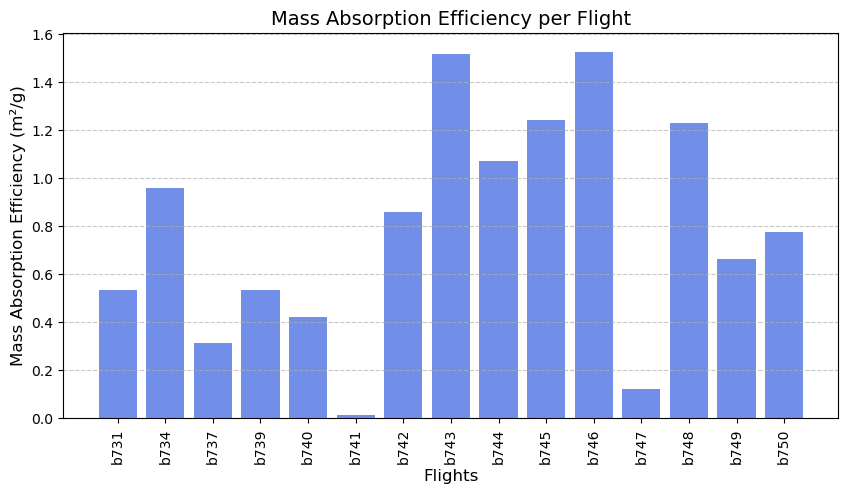

In [44]:
# Extract flight numbers and mass absorption efficiency values
flight_numbers = [res["flight"] for res in results]
mass_absorption_eff_g_values = [res["mass_absorption_eff_g"] for res in results]

# Create the plot
plt.figure(figsize=(10, 5))
plt.bar(flight_numbers, mass_absorption_eff_g_values, color='royalblue', alpha=0.75)

# Labels and title
plt.xlabel("Flights", fontsize=12)
plt.ylabel("Mass Absorption Efficiency (m²/g)", fontsize=12)
plt.title("Mass Absorption Efficiency per Flight", fontsize=14)
plt.xticks(rotation=90)  # Rotate x-axis labels for readability

# Add grid
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Show the plot
plt.show()